In [3]:
import pandas as pd
#from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/final_7features_state_IX.csv')

# Convert 'state' if needed
state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)

# 🔍 Check which columns you’re using
#feature_cols = [col for col in df.columns if col not in ['SOH', 'capacity', 'cycle', 'cell', 'T_C','state', 'Zmag_1000Hz','R_sei', 'R_s','Zmag_100Hz','C_dl_est','Zmag_0.1Hz','Zmag_10Hz','R_ct','tail_slope','tail_angle_deg','f_peak_main','Phase_100Hz', 'Phase_0.1Hz','Phase_1000Hz','Phase_10Hz']]  # Adjust as needed
#target_col = 'SOH'

In [4]:
train_groups = [(25, 6), (25, 7), (25, 8), (25, 5), (25, 3), (25, 4), (35, 1)]
val_groups   = [(25, 2), (45, 2)]                 # validation cell(s)
test_groups  = [(25, 1), (35, 2), (45, 1)]         # final test cell(s)

In [5]:
def mask_from_groups(df, groups):
    groups = set(groups)
    return df.apply(lambda r: (r["T_C"], r["cell"]) in groups, axis=1)

train_mask = mask_from_groups(df, train_groups)
val_mask   = mask_from_groups(df, val_groups)
test_mask  = mask_from_groups(df, test_groups)

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()
test_df  = df[test_mask].copy()

print("Train:", train_df.shape, "Groups:", sorted(set(zip(train_df.T_C, train_df.cell))))
print("Val  :", val_df.shape,   "Groups:", sorted(set(zip(val_df.T_C, val_df.cell))))
print("Test :", test_df.shape,  "Groups:", sorted(set(zip(test_df.T_C, test_df.cell))))


Train: (1279, 13) Groups: [(25, 3), (25, 4), (25, 5), (25, 6), (25, 7), (25, 8), (35, 1)]
Val  : (491, 13) Groups: [(25, 2), (45, 2)]
Test : (966, 13) Groups: [(25, 1), (35, 2), (45, 1)]


In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred)))
    }


In [7]:
features = [
    "R_s_rel",
    "R_ct_rel",
    "Zmag_0.1Hz_rel",
    "Zmag_1000Hz_rel",
    "C_dl_log",
    "tail_slope",
    "R_sei_rel",
    "T_C"

]  


X_train, y_train = train_df[features], train_df["SOH"]
X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]


linear regressor

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr.fit(X_train, y_train)
print("Linear Regression performance")
print("Train:", metrics(y_train, lr.predict(X_train)))
print("Val  :", metrics(y_val,   lr.predict(X_val)))
print("Test :", metrics(y_test,  lr.predict(X_test)))


Linear Regression performance
Train: {'R2': 0.8597883918950442, 'MAE': 0.05675666375412207, 'RMSE': 0.07386894700997344}
Val  : {'R2': 0.21548285101388953, 'MAE': 0.05180005620516011, 'RMSE': 0.06330128922231572}
Test : {'R2': 0.8737329718086836, 'MAE': 0.05592902173432941, 'RMSE': 0.06451863996225068}


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9

ridge

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

# Create Ridge model
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))  # you can tune alpha later
])

# Train
ridge.fit(X_train, y_train)

print("Ridge Regression performance")
print("Train:", metrics(y_train, ridge.predict(X_train)))
print("Val  :", metrics(y_val,   ridge.predict(X_val)))
print("Test :", metrics(y_test,  ridge.predict(X_test)))


Ridge Regression performance
Train: {'R2': 0.859601960412684, 'MAE': 0.057060927698063826, 'RMSE': 0.07391804038648571}
Val  : {'R2': 0.2138462604471768, 'MAE': 0.05226609346648448, 'RMSE': 0.06336728160999651}
Test : {'R2': 0.8707385377121999, 'MAE': 0.05650538475289875, 'RMSE': 0.06527918997253564}


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


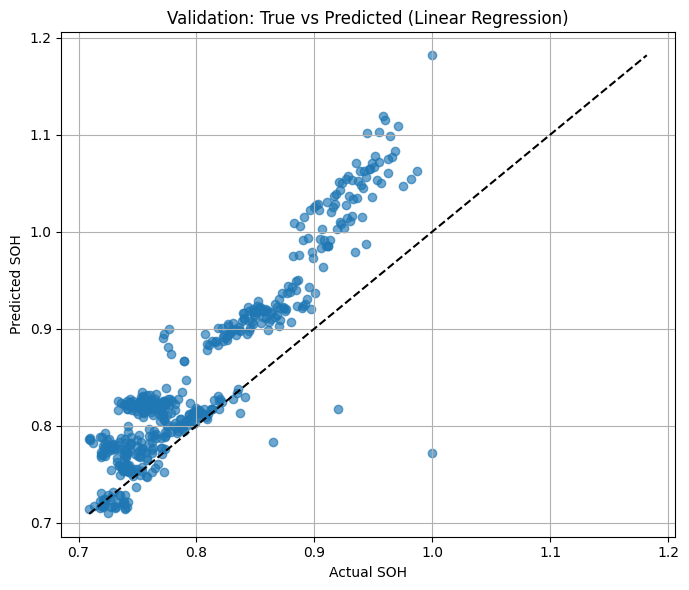

/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


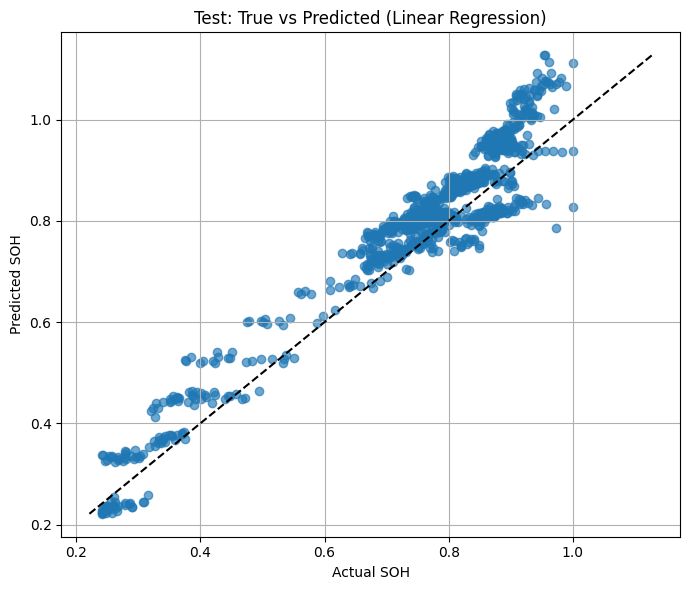

In [245]:
def true_vs_pred_plot(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(7,6))
    plt.scatter(y_true, y_pred, alpha=0.65)
    plt.plot([lo, hi], [lo, hi], "k--")
    plt.xlabel("Actual SOH")
    plt.ylabel("Predicted SOH")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

true_vs_pred_plot(y_val,  lr.predict(X_val),  "Validation: True vs Predicted (Linear Regression)")
true_vs_pred_plot(y_test, lr.predict(X_test), "Test: True vs Predicted (Linear Regression)")


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


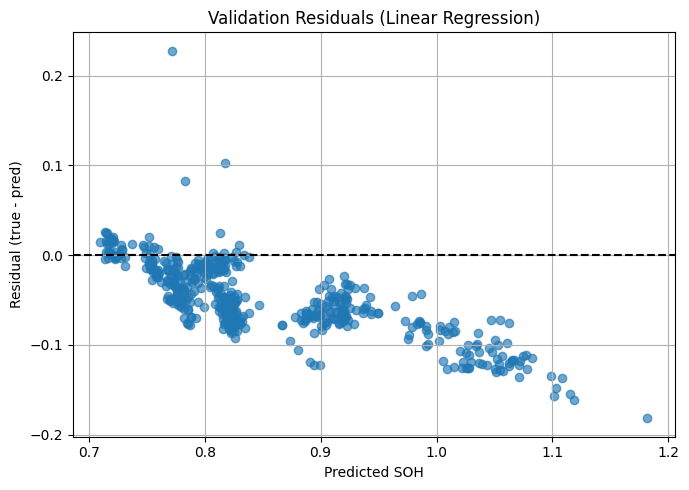

/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


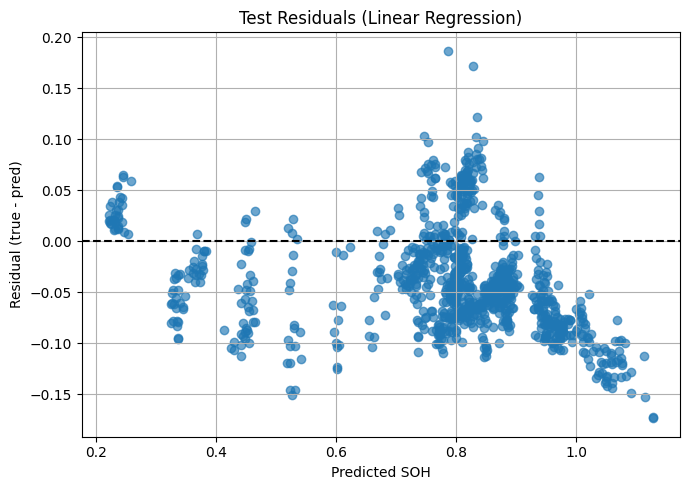

In [246]:
def residual_plot(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    resid = y_true - y_pred

    plt.figure(figsize=(7,5))
    plt.scatter(y_pred, resid, alpha=0.65)
    plt.axhline(0, linestyle="--", color="k")
    plt.xlabel("Predicted SOH")
    plt.ylabel("Residual (true - pred)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

residual_plot(y_val,  lr.predict(X_val),  "Validation Residuals (Linear Regression)")
residual_plot(y_test, lr.predict(X_test), "Test Residuals (Linear Regression)")


tuning of hyper parameters

In [247]:
from sklearn.linear_model import Ridge

alphas = np.logspace(-6, 6, 40)

best_model = None
best_rmse = np.inf
rows = []

for a in alphas:
    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=a))
    ])
    ridge.fit(X_train, y_train)
    val_pred = ridge.predict(X_val)
    rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))

    rows.append({"alpha": a, "val_rmse": rmse})
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = ridge
        best_alpha = a

tuning_df = pd.DataFrame(rows).sort_values("val_rmse")
print("Best alpha:", best_alpha, "Best Val RMSE:", best_rmse)
tuning_df.head(10)


Best alpha: 837.6776400682925 Best Val RMSE: 0.03434758681078888


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

,alpha,val_rmse
29,837.677640,0.034348
30,1701.254280,0.034406
28,412.462638,0.046338
31,3455.107295,0.051767
27,203.091762,0.056844
26,100.000000,0.062519
0,0.000001,0.063301
1,0.000002,0.063301
2,0.000004,0.063301
3,0.000008,0.063301


In [10]:
print("Best Ridge performance")
print("Train:", metrics(y_train, best_model.predict(X_train)))
print("Val  :", metrics(y_val,   best_model.predict(X_val)))
print("Test :", metrics(y_test,  best_model.predict(X_test)))


Best Ridge performance


NameError: name 'best_model' is not defined

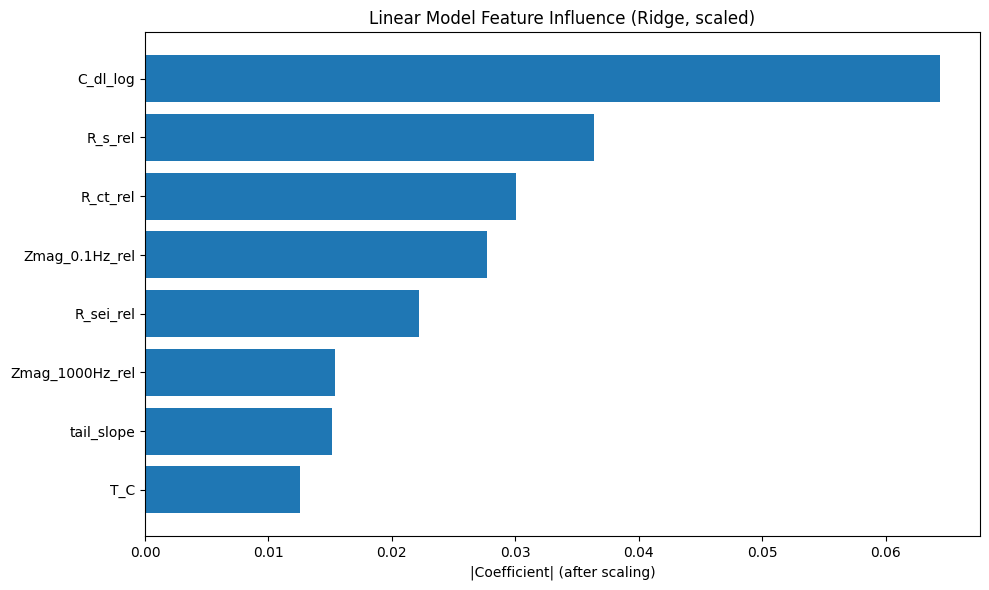

In [249]:
coef = best_model.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": features, "coef": coef, "abs_coef": np.abs(coef)}).sort_values("abs_coef", ascending=False)
coef_df
plt.figure(figsize=(10,6))
plt.barh(coef_df["feature"], coef_df["abs_coef"])
plt.gca().invert_yaxis()
plt.xlabel("|Coefficient| (after scaling)")
plt.title("Linear Model Feature Influence (Ridge, scaled)")
plt.tight_layout()
plt.show()